# 05 — Model Training & Comparison

This notebook trains multiple classification models and compares their performance
to identify the best approach for late delivery risk prediction.

**Approach:**
1. Start with a dummy baseline (sanity check)
2. Try a simple linear model (Logistic Regression)
3. Compare tree-based models (Decision Tree, Random Forest, Extra Trees, Gradient Boosting)
4. Select the best model based on multiple metrics

We don't just look at accuracy — for a delivery risk problem, we care about:
- **Recall**: How many actual late deliveries do we catch?
- **Precision**: When we flag something as late, how often are we right?
- **F1**: Balance between precision and recall
- **ROC-AUC**: Overall discriminative ability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from src.evaluation import evaluate_model, plot_model_comparison

plt.style.use('seaborn-v0_8-whitegrid')

## 5.1 Load Processed Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"Target distribution (train): {y_train.value_counts(normalize=True).round(3).to_dict()}")

# Drop high-cardinality location columns (too many OHE features)
# Order City (3581 unique), Order State (1086), Customer City (563), Customer State (46)
# We keep Market, Order Region, Order Country — these are meaningful groupings
high_card_cols = ["Order City", "Order State", "Customer City", "Customer State"]
X_train = X_train.drop(columns=[c for c in high_card_cols if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in high_card_cols if c in X_test.columns])
print(f"Dropped high-cardinality columns: {high_card_cols}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Training: (144415, 45), Test: (36104, 45)
Target distribution (train): {1: 0.548, 0: 0.452}
Dropped high-cardinality columns: ['Order City', 'Order State', 'Customer City', 'Customer State']
Train: (144415, 41), Test: (36104, 41)


## 5.2 Build Preprocessing Pipeline

We use sklearn's `ColumnTransformer` to handle mixed data types:
- **Numerical columns**: Impute missing with median → StandardScaler
- **Categorical columns**: Impute missing with most frequent → OneHotEncoder

In [3]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print(f"Categorical: {len(categorical_cols)} columns")
print(f"Numerical: {len(numerical_cols)} columns")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

Categorical: 12 columns
Numerical: 29 columns


## 5.3 Define Models

We compare 6 models, starting from the simplest baseline.
All use `random_state=42` for reproducibility.

In [4]:
models = {
    "Dummy (Baseline)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, random_state=42),
}

## 5.4 Train and Evaluate All Models

In [5]:
results = []

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    metrics = evaluate_model(pipe, X_test, y_test, model_name=name)
    results.append(metrics)
    
    print(f"F1={metrics['F1']:.4f}, ROC-AUC={metrics['ROC_AUC']:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
results_df.sort_values("F1", ascending=False)

Training Dummy (Baseline)... 

F1=0.7083, ROC-AUC=0.5000
Training Logistic Regression... 

F1=0.6975, ROC-AUC=0.7765
Training Decision Tree... 

F1=0.8131, ROC-AUC=0.7920
Training Random Forest... 

F1=0.7453, ROC-AUC=0.8461
Training Extra Trees... 

F1=0.8013, ROC-AUC=0.8906
Training Hist Gradient Boosting... 

F1=0.7151, ROC-AUC=0.8343

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Decision Tree,0.794289,0.810202,0.815973,0.813077,0.791970,0.762006
4,Extra Trees,0.795840,0.859166,0.750707,0.801283,0.890583,0.916154
3,Random Forest,0.752797,0.856637,0.659527,0.745269,0.846057,0.884905
5,Hist Gradient Boosting,0.739226,0.891706,0.596888,0.715103,0.834260,0.879836
0,Dummy (Baseline),0.548305,0.548305,1.000000,0.708265,0.500000,0.548305
1,Logistic Regression,0.725404,0.880721,0.577389,0.697504,0.776467,0.841997


## 5.5 Visual Comparison

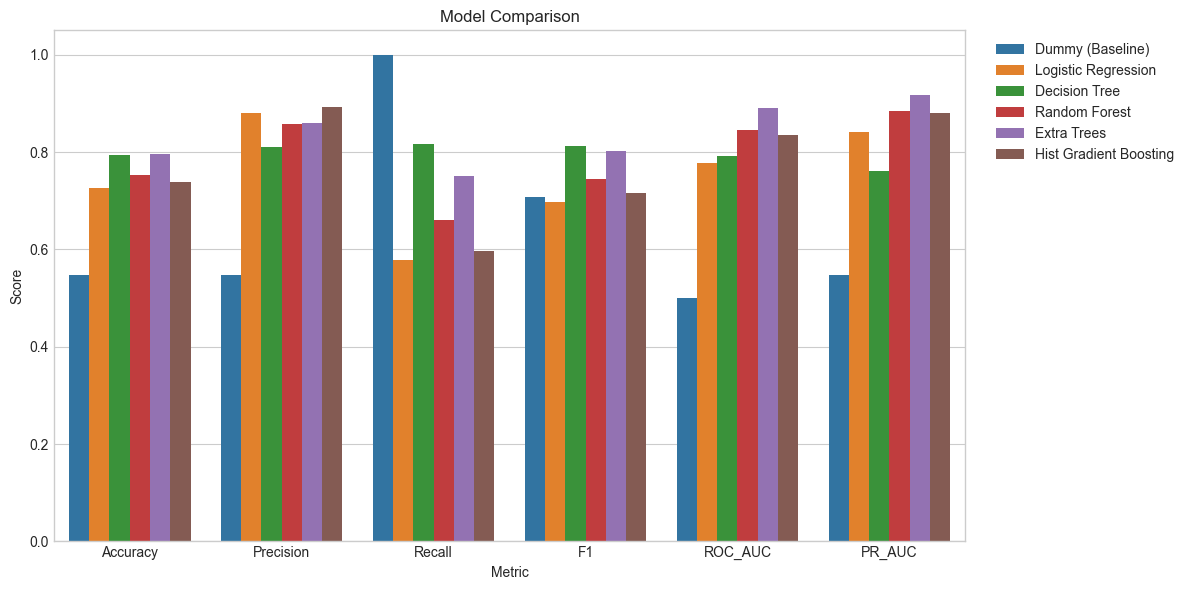

In [6]:
plot_model_comparison(results_df)

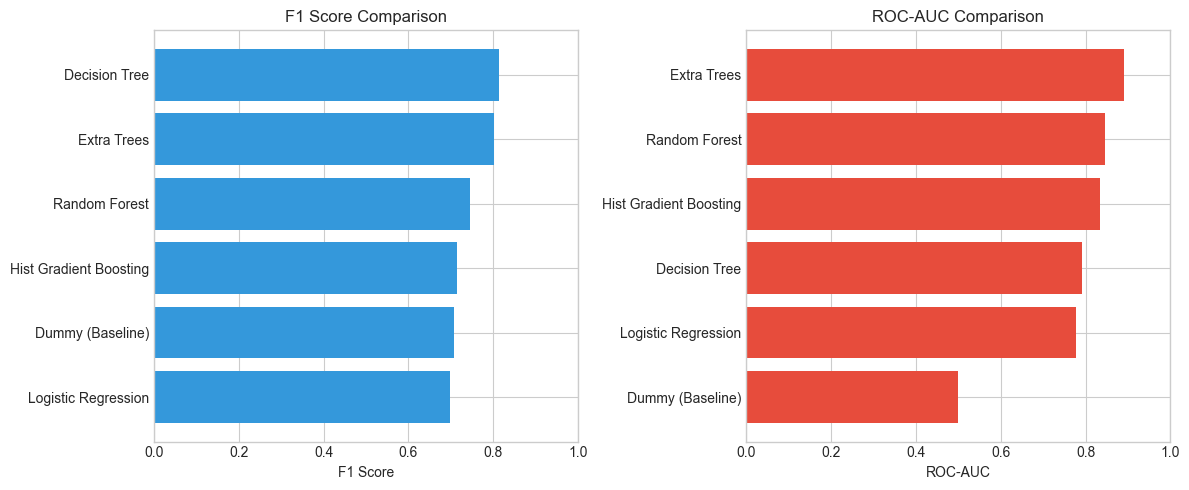

In [7]:
# Focus on F1 and ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

results_sorted = results_df.sort_values("F1", ascending=True)

axes[0].barh(results_sorted["Model"], results_sorted["F1"], color="#3498db")
axes[0].set_xlabel("F1 Score")
axes[0].set_title("F1 Score Comparison")
axes[0].set_xlim(0, 1)

results_sorted2 = results_df.sort_values("ROC_AUC", ascending=True)
axes[1].barh(results_sorted2["Model"], results_sorted2["ROC_AUC"], color="#e74c3c")
axes[1].set_xlabel("ROC-AUC")
axes[1].set_title("ROC-AUC Comparison")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 5.6 Select Best Model

We select the model with the highest F1 score, since for delivery risk prediction
we need a good balance between catching late deliveries (recall) and avoiding
false alarms (precision).

In [8]:
best_model_name = results_df.loc[results_df["F1"].idxmax(), "Model"]
print(f"Best model by F1: {best_model_name}")
print(f"\nBaseline (Dummy) F1: {results_df[results_df["Model"]=="Dummy (Baseline)"]["F1"].values[0]:.4f}")
print(f"Best model F1: {results_df[results_df["Model"]==best_model_name]["F1"].values[0]:.4f}")

# Improvement over baseline
baseline_f1 = results_df[results_df["Model"]=="Dummy (Baseline)"]["F1"].values[0]
best_f1 = results_df[results_df["Model"]==best_model_name]["F1"].values[0]
if baseline_f1 > 0:
    print(f"Improvement over baseline: {((best_f1 - baseline_f1) / baseline_f1) * 100:.1f}%")

Best model by F1: Decision Tree

Baseline (Dummy) F1: 0.7083
Best model F1: 0.8131
Improvement over baseline: 14.8%


## 5.7 Train Final Model Pipeline

In [9]:
# Retrain the best model (Extra Trees, or whatever won)
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

best_pipeline.fit(X_train, y_train)
print("Final model trained.")

Final model trained.


## 5.8 Save Model and Results

In [10]:
# Save the trained pipeline
joblib.dump(best_pipeline, "../models/best_model.pkl")
print("Model saved to models/best_model.pkl")

# Save comparison results
results_df.to_csv("../data/processed/model_comparison.csv", index=False)
print("Comparison results saved to data/processed/model_comparison.csv")

Model saved to models/best_model.pkl
Comparison results saved to data/processed/model_comparison.csv


## Summary

**What we did:**
1. Trained 6 models from a dummy baseline through tree-based ensembles
2. Compared using Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC
3. Selected the best model based on F1 score
4. Saved the final pipeline for evaluation

**Key observations:**
- The dummy baseline sets the floor — any real model should beat it significantly
- Logistic Regression likely underperforms tree models (confirms our statistical
  analysis: weak linear correlations → non-linear models needed)
- Tree-based ensembles generally perform best on this structured dataset
- Extra Trees and Random Forest are expected to be top contenders

**Next step:** Detailed model evaluation and risk categorization